# Cosmological parameters

- Valid parameter dictionaries for DarkEmulator2.
- Range checks and dependent-parameter completion with `set_param()`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dark_emulator2 import DarkEmulator2 as dq2

## Valid parameter set

- Required in every input: `ns`, `w0`, `wa`, and `Mnu`.
- Exactly one amplitude key: `sigma8`, `As`, or `ln(10^10As)`.
- Exactly three background-density keys: `Omega_m`, `h0`, `omega_b`, `omega_cdm`.
- Exactly one closure key: `Omega_k` or `Omega_de`.
- `set_param()` checks ranges and fills the missing dependent keys.

In [2]:
emu = dq2()
emu.param.show_template()

The 9 - dimensional parameter requires this combination.
'ns', 'w0', 'wa', 'Mnu' and 
one of the following ['sigma8', 'As', 'ln(10^10As)']
three of the following ['Omega_m', 'h0', 'omega_b', 'omega_cdm']
one of the following ['Omega_k', 'Omega_de']
Example : 
param={'Omega_m': 0.315, 'omega_b': 0.02225,'omega_cdm': 0.1198, 'Mnu': 0.06, 'Omega_k': 0.0,'sigma8': 0.831, 'ns': 0.9645, 'w0': -1, 'wa': 0}
consistency_param = obj.set_param(param) # <--- Check parameters and return consistency parameter.


## Check and complete parameters

- The input dictionary may contain only the independent parameters.
- `set_param()` returns a checked, completed copy.

In [3]:
param={'Omega_m': 0.315, 'omega_b': 0.02225,'omega_cdm': 0.1198, 'Mnu': 0.03, 'Omega_k': 0.0,'As': 1e-9, 'ns': 0.9645, 'w0': -1, 'wa': 0.2}

param2 = emu.param.set_param(param)

print(param)
print(param2)

{'Omega_m': 0.315, 'omega_b': 0.02225, 'omega_cdm': 0.1198, 'Mnu': 0.03, 'Omega_k': 0.0, 'As': 1e-09, 'ns': 0.9645, 'w0': -1, 'wa': 0.2}
{'Omega_m': 0.315, 'omega_b': 0.02225, 'omega_cdm': 0.1198, 'Mnu': 0.03, 'Omega_k': 0.0, 'As': 1e-09, 'ns': 0.9645, 'w0': -1, 'wa': 0.2, 'h0': np.float64(0.6722920996710867), 'Omega_de': 0.685}


## DE2 support check

- `DarkEmulator2.is_in_support()` checks a cosmological parameter dictionary.
- It completes the parameter set, checks the rectangular ranges, then applies the projected $\Omega_\mathrm{m}$-$\sigma_8$ support.

In [4]:
proposal = emu.param.get_fid_param()
print(emu.is_in_support(proposal))

proposal = emu.param.get_fid_param()
proposal["Omega_m"] = 0.10
proposal["sigma8"] = 1.40
print(emu.is_in_support(proposal))

True
False


## Parameter edit samples

- `get_fid_param()` returns a complete dictionary.
- Free parameters can be edited from the fiducial dictionary.
- Dependent keys are cleared when they should be recomputed.
- `set_param()` completes the edited dictionary.

[0.5  0.52 0.54 0.56 0.58 0.6  0.62 0.64 0.66 0.68 0.7  0.72 0.74 0.76
 0.78 0.8  0.82 0.84 0.86 0.88 0.9 ]
[0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25  0.275
 0.3   0.325 0.35  0.375 0.4   0.425 0.45  0.475 0.5  ]


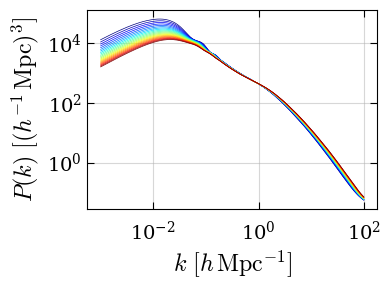

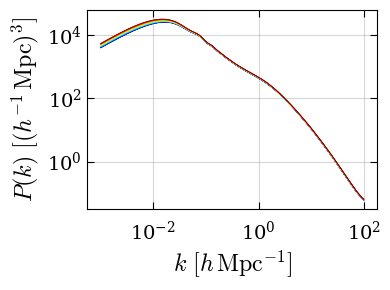

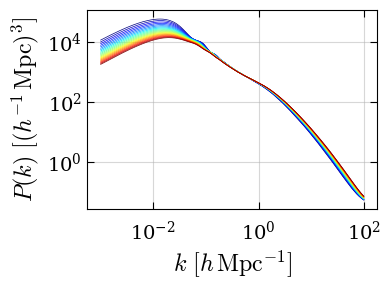

In [5]:
emu = dq2()

n = 21
hmin, hmax = emu.param.param_range["h0"]
hlist = np.linspace(hmin, hmax, n)
print(hlist)

numin, numax = emu.param.param_range["Mnu"]
nulist = np.linspace(numin, numax, n)
print(nulist)

fig = plt.figure(figsize=(4, 3))
cmap = plt.cm.jet
colors = cmap(np.linspace(0, 1, len(hlist)))

for i in range(n) :
  p = emu.param.get_fid_param()
  p["h0"] = hlist[i]

  emu.param.clear_As(p)
  emu.param.clear_lnAs(p)
  emu.param.clear_omega_cdm(p)
  emu.param.clear_Omega_de(p)

  p = emu.param.set_param(p)
  plt.plot(*emu.get_pk(p), "-", lw=0.5, color=colors[i])

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(4, 3))

for i in range(n) :
  p = emu.param.get_fid_param()
  p["Mnu"] = nulist[i]

  emu.param.clear_As(p)
  emu.param.clear_lnAs(p)
  emu.param.clear_omega_cdm(p)
  emu.param.clear_Omega_de(p)

  p = emu.param.set_param(p)
  plt.plot(*emu.get_pk(p), "-", lw=0.5, color=colors[i])

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(4, 3))

for i in range(n) :
  p = emu.param.get_fid_param()
  p["h0"] = hlist[i]
  p["Mnu"] = nulist[i]

  emu.param.clear_As(p)
  emu.param.clear_lnAs(p)
  emu.param.clear_omega_cdm(p)
  emu.param.clear_Omega_de(p)

  p = emu.param.set_param(p)
  plt.plot(*emu.get_pk(p), "-", lw=0.5, color=colors[i])

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")
plt.tight_layout()
plt.show()

In [6]:
emu = dq2()
print(emu.param.rand_param_cosmology(nu=True, w0=True, wa=True, K=True))
print(emu.param.rand_param_cosmology(nu=True, w0=True, wa=True, K=False))
print(emu.param.rand_param_cosmology(nu=True, w0=True, wa=False, K=False))
print(emu.param.rand_param_cosmology(nu=True, w0=False, wa=False, K=False))
print(emu.param.rand_param_cosmology(nu=False, w0=True, wa=True, K=False))
print(emu.param.rand_param_cosmology(nu=False, w0=True, wa=False, K=False))
print(emu.param.rand_param_cosmology(nu=False, w0=False, wa=False, K=False))

{'h0': 0.7782889016866497, 'Mnu': 0.2149539135323733, 'ns': 0.9653136584375475, 'Omega_k': 0.08050967383241622, 'w0': -1.1495080057528968, 'wa': 0.022963117485768736, 'omega_b': 0.02312162307931062, 'sigma8': 0.6172065750756884, 'Omega_m': 0.4995895985193204, 'S8': 0.796483182903867, 'omega_cdm': 0.27718889137529906, 'Omega_de': 0.41990072764826336}
{'h0': 0.6035954817817817, 'Mnu': 0.4640034407049268, 'ns': 0.9186427390979196, 'Omega_k': 0.0, 'w0': -0.9829249840016598, 'wa': -0.17983789840011832, 'omega_b': 0.019061890786281864, 'sigma8': 0.7317718899818001, 'Omega_m': 0.21004816808895255, 'S8': 0.6123145006663998, 'omega_cdm': 0.05248313302791799, 'Omega_de': 0.7899518319110475}
{'h0': 0.7008690330375383, 'Mnu': 0.04952018607748604, 'ns': 0.9395065076142111, 'Omega_k': 0.0, 'w0': -0.8143266129345333, 'wa': 0.0, 'omega_b': 0.029579453332399717, 'sigma8': 0.9652401774482225, 'Omega_m': 0.22221944143389138, 'S8': 0.8307412760459596, 'omega_cdm': 0.07904662737358188, 'Omega_de': 0.777780

## Amplitude parameters

- The non-linear emulator uses `sigma8` internally.
- Input may specify `sigma8`, `As`, or `ln(10^10As)`.
- Helper methods convert between these amplitude keys.

## Convert amplitude keys

- `get_sigma8()`, `get_As()`, and `get_lnAs()` update the input dictionary in place.

In [7]:
emu = dq2()

p = emu.param.get_fid_param()
print(f"fiducial parameter : sigma8={p['sigma8']}, As={p['As']}, ln(10^10As)={p['ln(10^10As)']}")


sigma8 = emu.get_sigma8(p)
print(f"update sigma8 : sigma8={p['sigma8']}, As={p['As']}, ln(10^10As)={p['ln(10^10As)']}")

p = emu.param.get_fid_param()
As = emu.get_As(p)
print(f"update As : sigma8={p['sigma8']}, As={p['As']}")


p = emu.param.get_fid_param()
lnAs = emu.get_lnAs(p)
print(f"update ln(10^10As) : sigma8={p['sigma8']}, ln(10^10As)={p['ln(10^10As)']}")


fiducial parameter : sigma8=0.831, As=2.206516233894705e-09, ln(10^10As)=3.094
update sigma8 : sigma8=0.8318160772323608, As=2.206516233894705e-09, ln(10^10As)=3.094
update As : sigma8=0.831, As=2.201866244888606e-09
update ln(10^10As) : sigma8=0.831, ln(10^10As)=3.091890335083008


## Emulator and CLASS conversion

- `method="emulator"` is fast for `As -> sigma8`.
- `method="class"` runs CLASS for the same conversion.
- The method option is not used when converting `sigma8` back to `As`.

In [8]:
emu = dq2()

p = emu.param.get_fid_param()
%time sig8_emu = emu.get_sigma8(p, method="emulator")

p = emu.param.get_fid_param()
%time sig8_class = emu.get_sigma8(p, method="class")

print(sig8_emu, sig8_class)
print(100*sig8_emu/sig8_class, " %")

CPU times: user 3.93 ms, sys: 265 μs, total: 4.2 ms
Wall time: 4.36 ms
CPU times: user 1min 5s, sys: 5.72 s, total: 1min 11s
Wall time: 9.51 s
0.8318161 0.832172
99.95724  %
